# Math preliminaries

先给你一个总图，然后一节一节拆开讲。你可以把 Lesson 8 理解成：“气象动力学的数学预科班”——它不真正讲方程本身，而是在帮你把之后所有大气运动方程里会出现的工具，一个个磨锋利.

# 0. 这节课整体在干嘛？

Lesson 8 的目标是：让你具备理解“运动学（kinematics）+ 动力学（dynamics）”的数学语言： 
- 你要用偏导数来描述“同一个物理量，沿不同方向/不同变量怎么变”
- 你要把风当成向量来算，学会点积、叉积、$\nabla$（del/gradient）算子
- 你要在不同坐标系（局地笛卡尔 vs 球坐标）和不同垂直坐标（$z$, $p$, $\theta$）之间切换
- 你要分清数学里的风向和气象里的风向，以及它们如何互相转换
- 你要理解梯度是什么，以及怎样从天气图上估计温度梯度
- 你要理解欧拉视角（固定点看风） vs 拉格朗日视角（跟着空气团一起飞）
- 最后用一个公式把这两种视角连接起来：物质导数 = 局地变化 + 平流

可以理解为：这节课在给你装一个“向量微积分 in the atmosphere 专用插件”。

# 8.1 偏导数其实很简单

## 1）从一元导数到多元导数

先回到一元函数：
- $f(x)$ 的导数 $\frac{df}{dx} = $“$x$ 变一点，$f$ 跟着怎么变”  

现在换成二维函数 $h(x,y)$，例如：
- $h(x,y)$ = 某个山地在平面坐标 $(x,y)$ 对应的高度。

问题：“朝东走一点，高度怎么变？”

做法：
- 把$y$固定在某个值$y=y_1$，当成常数
- 只在这条“$x$方向的切片”上对$x$做一元导数
- 这就是$\frac{\partial h}{\partial x}$：对$x$的偏导数 

同理，固定$x$，只看沿$y$方向变化，就是$\frac{\partial h}{\partial y}$。

Lesson 的核心观点：

偏导数并没有比普通导数“更复杂”，只是 “多变量里，一次只动一个，其它当常数”。 

在大气里：
- $T(x, y, z, t)$ = 四维温度场
- 你可以问：
- $\partial T / \partial x$：东西方向温度变化
- $\partial T / \partial y$：南北方向温度变化
- $\partial T / \partial z$：随高度变化
- $\partial T / \partial t$：时间变化

偏导数本质上就是“切开很多方向的局部斜率”。


# 8.2 向量：不只是带箭头的数

这一节先区分 标量 vs 向量： 
- 标量：只有大小，没有方向
- 例：温度 10°C，气压 1000 hPa，降雨量 5 mm
- 向量：既有大小，也有方向
- 例：风速 10 m/s，来自西北，吹向东南

课程通过 “速度 vs 速率” 来区分：
- 速率（speed）= 标量，只关心“有多快”
- 速度（velocity）= 向量，“多快 + 往哪儿走”
即使数值大小不变，只要方向变了，向量就“加速”了（比如匀速转弯）。 

在大气里，最重要的向量之一就是风矢量：
$\mathbf{U} = (u, v, w)$
- $u$：东西向分量（+ 向东）
- $v$：南北向分量（+ 向北）
- $w$：垂直分量（+ 向上）

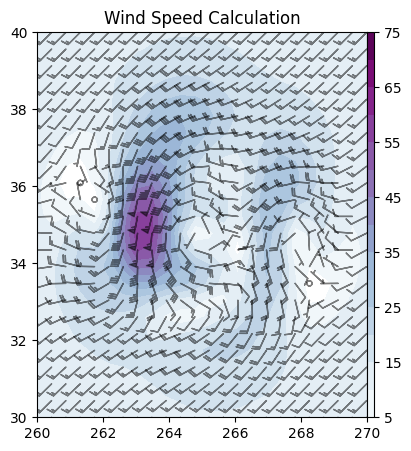

In [1]:
import matplotlib.pyplot as plt

import metpy.calc as mpcalc
from metpy.cbook import example_data

# load example data
ds = example_data()

# Calculate the total deformation of the flow
wind_speed = mpcalc.wind_speed(ds.uwind, ds.vwind)

# start figure and set axis
fig, ax = plt.subplots(figsize=(5, 5))

# plot wind speed
cf = ax.contourf(ds.lon, ds.lat, wind_speed, range(5, 80, 5), cmap=plt.cm.BuPu)
plt.colorbar(cf, pad=0, aspect=50)
ax.barbs(ds.lon.values, ds.lat.values, ds.uwind, ds.vwind, color='black', length=5, alpha=0.5)
ax.set(xlim=(260, 270), ylim=(30, 40))
ax.set_title('Wind Speed Calculation')

plt.show()

为什么要把风写成向量？因为后面所有动力方程基本都长这样：

“加速度 = 各种力的和（都是向量）”

向量运算中的两个核心：
	1.	点积 $\mathbf{A}\cdot\mathbf{B} = |A||B|\cos\theta$
- 几何意义：A 在 B 方向上的投影 × B 的长度
- 在大气里：把风投影到某个方向（比如沿等压线方向的风）

	2.	叉积 $\mathbf{A}\times\mathbf{B}$
- 得到一个垂直于 A、B 平面的向量，大小与“平行四边形面积”成正比
- 在大气中，会自然通向涡度这种转动量的概念（后面动量方程会用到）
- 右手定则，拇指指向叉积向量方向

再往下，课程引入了一个特殊的“向量”：

∇（del / gradient）算子 = “由偏导数组成的向量”

$$
\nabla = \left(\frac{\partial }{\partial x}, \frac{\partial }{\partial y}, \frac{\partial }{\partial z}\right)
$$

之后你会频繁看到诸如：
- $\nabla T$（温度梯度）
- $\mathbf{U} \cdot \nabla T$（温度平流）

整个 Lesson 8 很多后续内容，都是在利用这个 $\nabla$。 

In [16]:
import numpy as np
import metpy.calc as mpcalc

# Create coordinate grids
grid_lats, grid_lons = np.meshgrid(
    ds.coords['lat'].values,
    ds.coords['lon'].values,
    indexing='ij'
)
# Calculate the gradient of temperature in both latitude and longitude directions
grad = mpcalc.gradient(ds["temperature"].values, coordinates=(grid_lats, grid_lons))
print('Gradient in lat direction: ', grad[0])
print('Gradient in lon direction: ', grad[1])

Gradient in lat direction:  [[-1.000000000000007 -1.000000000000007 -1.000000000000007  -1.000000000000007 -1.000000000000007 -1.000000000000007  -1.000000000000007 -1.000000000000007 -1.000000000000007  -1.000000000000007 -1.000000000000007 -1.000000000000007  -1.000000000000007 -1.000000000000007 -1.000000000000007  -1.000000000000007 -1.000000000000007 -1.000000000000007  -1.000000000000007 -1.000000000000007 -1.000000000000007  -1.000000000000007 -1.000000000000007 -1.000000000000007] [-1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0  -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0] [-1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0  -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0] [-1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0  -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0] [-1.0000000000000036 -1.0000000000000036 -1.0000000000000036  -1.0000000000000036 -1.0000000000000036 -1.0000000000000036  -1.00000000000

# 8.3 坐标系统：地球不是平的但我们可以假装

主要是两种：局地笛卡尔和球坐标，外加三种“竖直坐标”。 

## 1）局地笛卡尔坐标（local Cartesian）

约定：
- 原点 (0,0,0) 可以任意选
- $x$：向东为正，向西为负
- $y$：向北为正，向南为负
- $z$：向上为正，向下为负
- 位置矢量：$\mathbf{r} = i x + j y + k z$，其中 $i/j/k$ 是单位向量（东、北、上） 

这个系适合尺度不太大的问题——比如一个州/一个中纬度天气系统，地球曲率可以暂时假装不存在。

## 2）球坐标（spherical）

当你要做全球尺度（行星波、Hadley 环流等），地球的“球”属性就不能忽略了。球坐标中： 
- $r$：到地心距离
- $\phi$：纬度（−90° ～ +90°）
- $\lambda$：经度（−180° ～ +180°）

细节他们强调两点：
- 1° 纬度 ≈ 111 km，总是差不多固定
- 1° 经度 = 111 km × $cos(\phi)$，越靠近极区东西距离越短

两点之间的距离要通过球面余弦定理算出夹角，再乘地球半径 6371 km。 

Lesson 的总结是：

“中小尺度（synoptic 或更小） → 用局地笛卡尔；更大尺度 → 必须用球坐标。” 

## 3）竖直坐标：$z$、$p$、$\theta$

三个垂直方向的“坐标”各有用途：

1.	高度 z
	- 单位 m 或 km
	- 航空、日常直觉最常用（飞行高度、雷达仰角等）

2.	气压 $p$（或 $\ln p$）
	- 气压随高度大致指数衰减 $p = p_0 e^{-z/H}$
	- $\ln(p)$ 对 $z$ 几乎线性，所以在动力学中、尤其是模式里，用等压面（700 hPa、500 hPa 那套）非常方便
	
3.	位温 $\theta$
	- 定义：空气团无热交换地被带到 1000 hPa 时的温度
	- 性质：绝热（不换热）上升或下降时，$\theta$ 不变
	- 所以大气常常沿等位温面运动——尤其在平流层
	- 这帮你看出“空气在能量几乎不变化的情况下是怎么滑动的”

# 8.4 数学风向 vs 气象风向：两个完全不一样的习惯

这一节就干一件事：统一“从哪儿吹来的风”跟“往哪儿吹去的向量”之间的语言。 

## 1）数学风向约定

- 风向量 $\mathbf{U} = i u + j v + k w$ 指向风吹去的方向
- 水平风 $\mathbf{U_H} = i u + j v$，大小 $U_H = \sqrt{u^2 + v^2}$
- 数学角度 $\alpha$：
- 从 $x$ 轴（向东）开始，逆时针增加
- $\tan \alpha = v / u$ 

## 2）气象风向约定

- 报天气时说“东北风”“西北风”，指的是风从哪里来
- 用 δ 表示风向：
- 北风（吹向南） ：δ = 0°
- 东风（吹向西） ：δ = 90°
- 南风（吹向北） ：δ = 180°
- 西风（吹向东） ：δ = 270° 
- δ 是从北开始，顺时针增加

所以：

- 数学角：“去哪儿” & 从东逆时针
- 气象角： “从哪儿来” & 从北顺时针

这俩差很多，因此必须有一个转换公式。教材通过一个图（风羽 + 坐标轴）告诉你：用几何画一画，很容易写出关系式，并给了示例（南风、西风、南西风）。 

直观记法：
- 画出风向（比如“西风”从西吹向东），在坐标轴上延长“吹去的线”，你就能读出数学角度。
- 公式本身不重要，重要是你知道两套约定并不一样且可以互相转化。

# 8.5 梯度：风为什么总喜欢切着等温线吹？

## 梯度 = “某个标量在空间中最大变化的方向和强度”

以温度为例：
- 温度场 $T(x,y,z)$，它的梯度 $\nabla T$ 是一个向量
- 方向：温度升高最快的方向
- 大小：单位距离上温度改变了多少（单位 K/km 等）

在三维笛卡尔坐标里：
$$
\nabla T =
\left(
\frac{\partial T}{\partial x},
\frac{\partial T}{\partial y},
\frac{\partial T}{\partial z}
\right)
$$
如果只关心水平变化（天气图上）：
$$
\nabla_H T =
\left(
\frac{\partial T}{\partial x},
\frac{\partial T}{\partial y}
\right)  
$$
教材强调了一个很重要的几何事实：

:::{important}
梯度总是垂直于等值线（如等温线、等压线），指向数值增大的那侧。  
:::

## 具体怎么从天气图上算梯度？

他们用 2012 年 9 月 8 日美国地面温度图做例子： 
1.	找一个点（比如肯塔基州西部）
2.	看看这个点周围的等温线如何排布：
	- 如果东南方温度明显高、西北方温度低，那 $\nabla T$ 大致指向东南
3.	要估大小，就要用到有限差分：
	- 沿 x 方向：$\partial T / \partial x \approx \Delta T/\Delta x$
	- 沿 y 方向：$\partial T / \partial y \approx \Delta T/\Delta y$  
4.	再用：
	- 大小：$|\nabla T| = \sqrt{\left(\partial T/\partial x\right)^2 + \left(\partial T/\partial y\right)^2}$
	- 方向角：$\tan\theta = (\partial T/\partial y)/(\partial T/\partial x)$

他们甚至专门讲了如何用尺子量地图上的实际距离，把“厘米”换成“海里或公里”，再套进 $\Delta T/\Delta x$ 里算梯度。 


# 8.6 欧拉 vs 拉格朗日：你是站在窗边，还是在云里飞？

这一节的核心是一个画面： 

一辆车以和雷暴云相同的速度和方向在地面行驶，始终待在暴雨下方。
- 对司机来说：一路上“雨一直在下”。
- 对路边房子里的居民：暴雨只在头顶停留 ~20 分钟就走了。

于是：
- 房子里的观测者：
	- 固定在某个点
	- 只在云飘过头顶时被雨“扫一下”
	- 这是 欧拉视角（Eulerian）：在固定位置上观测随时间变化的物理量
- 车里的司机：
	- 跟着云一起走
	- 体验的是这团云本身“内部”强弱变化
	- 这是 拉格朗日视角（Lagrangian）：跟随同一空气团，看它自身的演化

接着引入一个核心概念：
:::{important}
空气包裹（air parcel） 
- 一个理想化的“小块空气”
- 质量和组成在运动中基本守恒（不不断混入其它空气）
- 尺寸要足够大，使 $T$、$p$ 等热力学量“有意义”；又要足够小，可以快速响应环境变化
:::

然后总结两种框架的特点： 

Eulerian 框架：
- 固定位置记录变量随时间变化（天气站、塔、雷达格点）
- 看到的是“不同空气团依次路过”的效果
- 是数值天气预报模式、观测网络的主流方式

Lagrangian 框架：
- 跟着单个空气团走，看这个团内部的 $T$、$q$、$p$ 等如何变化
- 更容易联系物理过程（绝热上升、凝结、加热冷却）
- 实际观测中不好实现，多用于理论和数值实验

教材还指出：探空（radiosonde）既不是纯 Eulerian（它会飘走），也不是纯 Lagrangian（它不会牢牢跟住同一团空气），属于“两边都沾点但都不完全”。 

# 8.7 用一个公式连接两种视角：物质导数 & 平流

现在进入本课最核心的数学连接：Eulerian vs Lagrangian 用一个公式打通。 

设一个标量 $R(x, y, z, t)$（比如降雨率），它依赖空间和时间。

## 1）从全微分出发

先写 $R$ 的全微分：
$$
dR =
\frac{\partial R}{\partial t} dt +
\frac{\partial R}{\partial x} dx +
\frac{\partial R}{\partial y} dy +
\frac{\partial R}{\partial z} dz  
$$
把两边都除以 dt：
$$
\frac{dR}{dt} =
\frac{\partial R}{\partial t} +
\frac{\partial R}{\partial x}\frac{dx}{dt} +
\frac{\partial R}{\partial y}\frac{dy}{dt} +
\frac{\partial R}{\partial z}\frac{dz}{dt}
$$
注意：
$- \frac{dx}{dt}, \frac{dy}{dt}, \frac{dz}{dt}$ 正是空气团的速度分量 $u$, $v$, $w$

于是：
$$
\frac{dR}{dt} =
\frac{\partial R}{\partial t} +
u \frac{\partial R}{\partial x} +
v \frac{\partial R}{\partial y} +
w \frac{\partial R}{\partial z}
$$
这就是物质导数（substantial / material / Lagrangian derivative）：

“跟着空气团移动时，$R$ 的变化率”。 

用向量写得更优雅：
$$
\frac{dR}{dt} = \frac{\partial R}{\partial t} + \mathbf{U} \cdot \nabla R
$$
其中第二项 $\mathbf{U} \cdot \nabla R$ 就是advective derivative（平流导数）。 

## 2）Euler 关系：局地变化 = 物质变化 – 平流

把公式稍微变个形：
$$
\frac{\partial R}{\partial t} =
\frac{dR}{dt} - \mathbf{U} \cdot \nabla R  
$$
解释：
- 左边：固定在一个观测站，看 $R$ 随时间如何变化（Eulerian 局地导数）
- 第一项：空气团自己“内在”变化（加热、冷却、凝结等）（Lagrangian 物质导数）
- 第二项：因为空气在空间中移动，带来了原本在别处的 $R$ 值（平流 advection）

他们特别强调：advection 只是 advective derivative 的负号，只是符号约定问题。 

## 3）用温度平流来感受符号

例子：只在 $x$ 方向有温度梯度，$T$ 往东升高：
- 即 $\partial T / \partial x > 0$
- 风是西风（$u > 0$，风从西往东吹） 

那平流项里 $u$ 和 $\partial T / \partial x$ 都是正的，于是：
- 温度平流（定义成 $-u \partial T / \partial x$）是负值 → 冷平流（cold advection）
- 物理意义：
- 你站在某点，右边更暖，左边更冷，风从左往右吹
- 随着时间过去，你脚下的位置被“更冷的空气替换掉”，温度在下降
- 所以 $\partial T / \partial t$ < 0

类似地，如果平流项是正的，就是暖平流（warm advection）。 

这一套结构非常通用：
- $R$ 可以是降雨率、温度、气压、湿度等任何标量
- 你只需要给出 $\mathbf{U}$ 和 $\nabla R$，就能写出“R 的局地变化 = 物质变化 – 平流”的平衡

kelvin / second


/tmp/ipykernel_2433/3945998008.py:10: UserWarning: Vertical dimension number not found. Defaulting to (..., Z, Y, X) order.
  tadv = mpcalc.advection(ds.temperature, ds.uwind, ds.vwind)


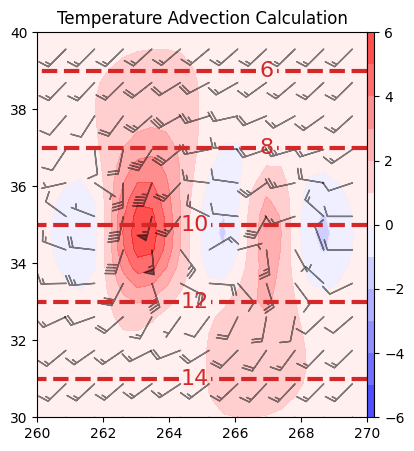

In [2]:
import matplotlib.pyplot as plt

import metpy.calc as mpcalc
from metpy.cbook import example_data

# load example data
ds = example_data()

# Calculate the temperature advection of the flow
tadv = mpcalc.advection(ds.temperature, ds.uwind, ds.vwind)

# See the units that come back from the advection function
print(tadv.data.units)

# start figure and set axis
fig, ax = plt.subplots(figsize=(5, 5))

# plot isotherms
cs = ax.contour(ds.lon, ds.lat, ds.temperature, range(4, 26, 2), colors='tab:red',
                linestyles='dashed', linewidths=3)
plt.clabel(cs, fmt='%d', fontsize=16)

# plot temperature advection and convert units to Kelvin per 3 hours
cf = ax.contourf(ds.lon, ds.lat, tadv.metpy.convert_units('kelvin/hour') * 3, range(-6, 7, 1),
                 cmap=plt.cm.bwr, alpha=0.75)
plt.colorbar(cf, pad=0, aspect=50)
ax.barbs(ds.lon.values[::2], ds.lat.values[::2],
         ds.uwind[::2, ::2], ds.vwind[::2, ::2],
         color='black', length=6, alpha=0.5)
ax.set(xlim=(260, 270), ylim=(30, 40))
ax.set_title('Temperature Advection Calculation')

plt.show()

# 9. 总结：Lesson 8 = 给“动力学方程”铺好语言地板

整节课的 Summary 明说了：
- 你现在具备后面所有运动学（流线、发散、旋度）和动力学（力平衡、涡度方程）的数学工具箱：偏导数、向量、点积/叉积、$\nabla$、梯度、坐标系、风向约定、欧拉/拉格朗日、物质导数、平流。 

如果用一句更“气象人”的话来概括 Lesson 8：

它在教你：如何用向量微积分和两种视角（Eulerian/Lagrangian）来“听懂”风在说什么。